1) Découpage en slices 2D
Tu prends ton volume IRM 3D (par ex. NIfTI .nii.gz)

Tu l’extrais en coupes 2D (axiales, coronales ou sagittales).

Tu passes chaque coupe dans MedSAM (comme une image 2D).

Tu reconstruis ensuite le volume segmenté en empilant les masques prédits. 👉 Avantage : simple, compatible avec MedSAM standard. 👉 Limite : cohérence inter‑coupes pas garantie.


2. Utiliser MedSAM‑2 ou MedLSAM
MedSAM‑2 traite les volumes 3D comme des séquences (similaire à une vidéo).

MedLSAM (Localize & Segment Anything Model) est une extension pensée pour la 3D médicale. 👉 Avantage : meilleure cohérence spatiale 3D. 👉 Limite : modèles plus lourds, encore en recherche active.

Si tu veux tester rapidement → utilise 3D Slicer + MedSAMSlicer.

Si tu veux un pipeline Python → découpe ton IRM en slices 2D et applique MedSAM.

Si tu veux de la vraie 3D → regarde MedSAM‑2 ou MedLSAM (plus avancés).

In [1]:
import torch
import os
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
img_dir = "D:/marchine_learning/Projet/Segmentation/BraTS2023_Preprocessed/input_data_128/train/images"
mask_dir = "D:/marchine_learning/Projet/Segmentation/BraTS2023_Preprocessed/input_data_128/train/masks"

In [3]:
class BratsDataset(Dataset):
  def __init__(self, img_dir, mask_dir, normalization=True):
    super().__init__()

    self.img_dir = img_dir
    self.mask_dir = mask_dir
    self.img_list = sorted(
        os.listdir(img_dir)
    )
    self.mask_list = sorted(os.listdir(mask_dir))
    self.normalization = normalization

    # If normalization is True, set up a normalization transform
    if self.normalization:
        self.normalizer = transforms.Normalize(
            mean=[0.5], std=[0.5]
        )  

  def load_file(self, filepath):
    return np.load(filepath)

  def __len__(self):
    return len(self.img_list)

  def __getitem__(self, idx):
    image_path = os.path.join(self.img_dir, self.img_list[idx])
    mask_path = os.path.join(self.mask_dir, self.mask_list[idx])
    # Load the image and mask
    image = self.load_file(image_path)
    mask = self.load_file(mask_path)

    # Convert to torch tensors and permute axes to C, D, H, W format (needed for 3D models)
    image = torch.from_numpy(image).permute(3, 2, 0, 1)  # Shape: C, D, H, W
    mask = torch.from_numpy(mask).permute(3, 2, 0, 1)  # Shape: C, D, H, W

    # Normalize the image if normalization is enabled
    if self.normalization:
        image = self.normalizer(image)

    return image, mask

In [4]:
train_dataset = BratsDataset(img_dir, mask_dir, normalization=False)

train_loader = DataLoader(
    train_dataset, 
    batch_size=2,  
    shuffle=True, 
    num_workers=0,  
    pin_memory=True if torch.cuda.is_available() else False
)

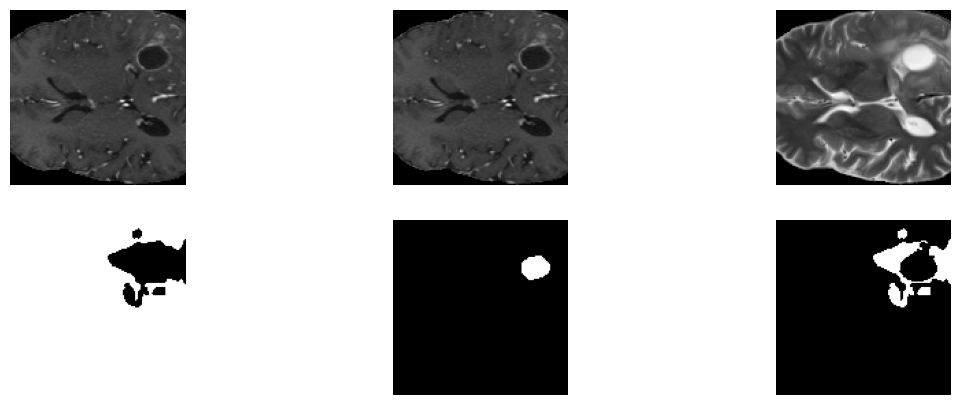

In [14]:
idx = np.random.randint(228)
image, mask  = train_dataset[idx]
image_flair = image[0,:,:,:].numpy()
image_t1ce = image[1,:,:,:].numpy() 
image_t2 = image[2,:,:,:].numpy() 

mask_flair = mask[0,:,:,:].numpy()
mask_t1ce = mask[1,:,:,:].numpy() 
mask_t2 = mask[2,:,:,:].numpy() 

max_img_ints = [np.max(image_flair, axis= 0), 
                np.max(image_t1ce, axis= 0),
                np.max(image_t2, axis= 2)]

middle_slice = image_flair.shape[0] // 2
img_slice = [image_flair[middle_slice, :, :], 
             image_t1ce[middle_slice, :, :], 
             image_t2[middle_slice, :, :]]

mask_slice = [mask_flair[middle_slice, :, :], 
             mask_t1ce[middle_slice, :, :], 
             mask_t2[middle_slice, :, :]]

plt.figure(figsize=(14, 5)) 
for i in range(3):
    plt.subplot(2,3, i + 1)
    plt.axis('off')
    plt.imshow(img_slice[i], cmap= 'gray')

for i in range(3):
    plt.subplot(2,3, i + 4)
    plt.axis('off')
    plt.imshow(mask_slice[i], cmap= 'gray')

plt.show()

In [17]:
import torch
from segment_anything import SamPredictor, sam_model_registry

MODEL_TYPE = "vit_b"
CHECKPOINT_PATH = "D:/marchine_learning/Projet/Segmentation/MedSam/model/medsam_vit_b.pth" # Le chemin vers votre fichier .pth téléchargé
DEVICE = "cpu"

print(f"Chargement de MedSAM sur : {DEVICE}")
print(os.path.exists(CHECKPOINT_PATH))

sam = sam_model_registry[MODEL_TYPE]()
state_dict = torch.load(CHECKPOINT_PATH, map_location=torch.device("cpu"))

# 3. Appliquer les poids
sam.load_state_dict(state_dict)
sam.to(device=DEVICE)
sam.eval()

# 5. Créer le prédicteur
predictor = SamPredictor(sam)

# if image is load clear it
def clear_image(predictor):
    if predictor.is_image_set:
        predictor.reset_image()
        print(predictor.is_image_set)

Chargement de MedSAM sur : cpu
True


In [ ]:
slide_norm = (img_slice[1] * 255).astype(np.uint8)
image_rgb = cv2.cvtColor(slide_norm, cv2.COLOR_BGR2RGB)
mask_ref = (mask_slice[1] * 255).astype(np.uint8)


# --- 5. Exécuter la Prédiction ---
clear_image(predictor)
predictor.set_image(image_rgb)

In [34]:
# features
predictor.get_image_embedding().size()
predictor.features.size()

torch.Size([1, 256, 64, 64])

In [ ]:
def select_center_prompts(mask, ratio_near=0.02, ratio_far=0.05):

    rows, cols = np.where(mask == 255)
    coords = np.stack([rows, cols], axis=1)
    center = np.mean(coords, axis=0)
    distances = np.linalg.norm(coords - center, axis=1)

    # Sélection des points proches
    sorted_idx = np.argsort(distances)
    n_near = max(1, int(ratio_near * len(coords)))
    near_coords = coords[sorted_idx[:n_near]]
    n_far = max(1, int(ratio_far * len(coords)))
    far_coords = coords[sorted_idx[-n_far:]]

    # Point central (arrondi aux indices entiers)
    center_coord = np.round(center).astype(int).reshape(1,2)

    # Concaténer
    selected_coords = np.vstack([center_coord, near_coords, far_coords])
    selected_labels = np.ones(len(selected_coords), dtype=np.int32)
    selected_labels = np.ones(len(selected_coords), dtype=np.int32)
    
    return (rows, cols), selected_coords, selected_labels


In [40]:
# Coordonnées (x, y) et label (1 pour le premier plan)
white_rows, white_cols = np.where(mask_ref == 255)
black_rows, black_cols = np.where(mask_ref == 0)
max_points = int(len(white_rows) * 0.05)
input_point = []
for i in range(max_points):
    idx = np.random.randint(len(white_rows))
    input_point.append([int(black_cols[idx]), int(black_rows[idx])])

input_point = np.array(input_point)
input_label = np.zeros(len(input_point))
x_min, y_min = min(white_cols).item(), min(white_rows).item()
x_max, y_max = max(white_cols).item(), max(white_rows).item()
input_box = np.array([(x_min, y_min), (x_max, y_max)])

print("Début de l'inférence (cela sera très lent sur CPU)...")
masks_sam, scores, logits = predictor.predict(
    #point_coords=input_point,
    #point_labels=input_label,
    box=input_box,
    #mask_input=mask_input,
    multimask_output=True,
)

print(f"Segmentation terminée. Masque trouvé de forme : {masks_sam.shape}")


Début de l'inférence (cela sera très lent sur CPU)...
Segmentation terminée. Masque trouvé de forme : (3, 128, 128)


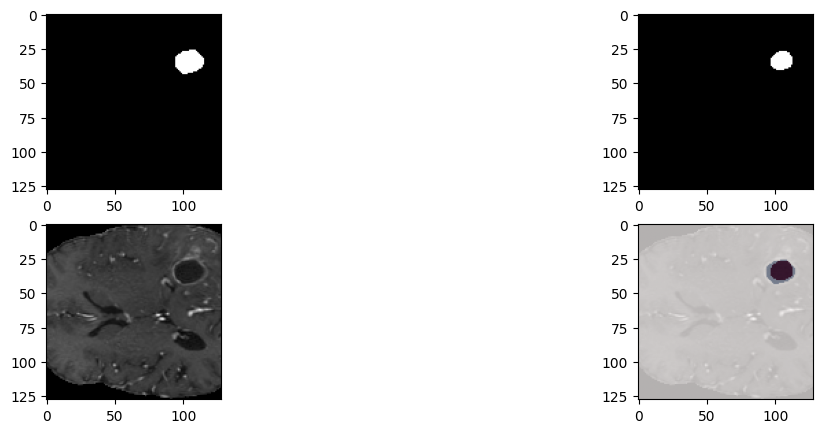

In [55]:

plt.figure(figsize=(14, 5)) 
plt.subplot(2,2, 1)
plt.imshow(mask_ref, cmap='gray')
plt.subplot(2,2, 2)
plt.imshow(masks_sam[0], cmap='gray')
plt.subplot(2,2, 3)
plt.imshow(img_slice[1], cmap= 'gray')
plt.subplot(2,2, 4)
plt.imshow(img_slice[1], cmap='gray')
plt.imshow(masks_sam[1], alpha=0.6, cmap='Reds')
plt.imshow(mask_ref, alpha=0.3, cmap='Blues')

In [57]:
def dice(mask_ref, mask_sam):
    """
    Calcule le Dice coefficient entre deux masques binaires.
    mask_ref : numpy array (0/1 ou bool)
    mask_sam : numpy array (0/1 ou bool)
    """
    mask_ref = mask_ref.astype(bool)
    mask_sam = mask_sam.astype(bool)

    intersection = np.logical_and(mask_ref, mask_sam).sum()
    size_ref = mask_ref.sum()
    size_sam = mask_sam.sum()

    if size_ref + size_sam == 0:
        return 1.0  # cas particulier : deux masques vides
    return 2.0 * intersection / (size_ref + size_sam)

In [64]:
dice(mask_ref, masks_sam[2])

np.float64(0.7521739130434782)

In [ ]:
import SimpleITK as sitk

# Charger un volume 3D
img = sitk.ReadImage("patient_ct.nii.gz")
arr = sitk.GetArrayFromImage(img)  # shape: (Z, Y, X)

from itkwidgets import view

# Affichage volumique interactif
view(img)


False


In [ ]:
import vtk
from vtk.util import numpy_support

# Convertir NumPy → VTK
vtk_data = numpy_support.numpy_to_vtk(arr.ravel(), deep=True, array_type=vtk.VTK_FLOAT)
image = vtk.vtkImageData()
image.SetDimensions(arr.shape[2], arr.shape[1], arr.shape[0])
image.GetPointData().SetScalars(vtk_data)

# Mapper volume
volumeMapper = vtk.vtkSmartVolumeMapper()
volumeMapper.SetInputData(image)

# Propriétés du volume
volumeProperty = vtk.vtkVolumeProperty()
volumeProperty.ShadeOn()
volumeProperty.SetInterpolationTypeToLinear()

# Volume
volume = vtk.vtkVolume()
volume.SetMapper(volumeMapper)
volume.SetProperty(volumeProperty)

# Renderer
renderer = vtk.vtkRenderer()
renderer.AddVolume(volume)
renderer.SetBackground(0, 0, 0)

# Fenêtre
renderWindow = vtk.vtkRenderWindow()
renderWindow.AddRenderer(renderer)

# Interacteur
renderWindowInteractor = vtk.vtkRenderWindowInteractor()
renderWindowInteractor.SetRenderWindow(renderWindow)

renderWindow.Render()
renderWindowInteractor.Start()


In [ ]:
def dice():
    pass

In [ ]:
def save_enbelding():
    type_img = ["input_flair", "input_t1", "input_t2"]
    img_emb = np.array([8,8])
    
    np.save(
            f"BraTS2023_embeddings/{type_img}/emb_image_"
            + str(idx)
            + ".npy",
            img_emb,
    )